# Intelligent Customer Segmentation and Marketing Campaign Optimization System
**Course:** Data Science (BE05016021) â€“ PBL Activity, L.D. College of Engineering
**Author:** Manasvi
**Dataset:** Customer Personality Analysis (Kaggle) â€“ 2,240 customers, 29 attributes

**Objectives**
1. Clean and prepare customer data (feature engineering)
2. Descriptive analytics (EDA) to understand customer behaviour
3. Sampling & Estimation â€“ confidence intervals and hypothesis tests
4. Linear Regression â€“ predict customer total spending
5. Customer Segmentation â€“ K-Means clustering
6. Classification â€“ Logistic Regression, Decision Tree, Random Forest to predict campaign response
7. Interactive Streamlit dashboard for business stakeholders

In [1]:
import os, sys, warnings
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.append(os.getcwd())
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import utils

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 100
os.makedirs("figures", exist_ok=True)
os.makedirs("models", exist_ok=True)

def save(name):
    plt.tight_layout()
    plt.savefig(f"figures/{name}.png", dpi=150, bbox_inches="tight")

## Step 1: Data Understanding and Cleaning
### 1.1 Load the raw data
The Kaggle file is **tab separated**, so we use `sep='\t'`.

In [2]:
raw = utils.load_raw()
print("Shape:", raw.shape)
raw.head()

Shape: (2240, 29)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [3]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

### 1.2 Data quality checks
We check for missing values, constant columns, duplicate rows and invalid values.

In [4]:
print("Missing values:\n", raw.isna().sum()[raw.isna().sum() > 0], "\n")
print("Duplicate rows:", raw.drop(columns="ID").duplicated().sum(), "\n")
print("Constant columns:", [c for c in raw.columns if raw[c].nunique() == 1], "\n")
print("Education values:", raw["Education"].value_counts().to_dict(), "\n")
print("Marital_Status values:", raw["Marital_Status"].value_counts().to_dict(), "\n")
print("Oldest birth year:", raw["Year_Birth"].min(), "| Max income:", raw["Income"].max())

Missing values:
 Income    24
dtype: int64 

Duplicate rows: 182 

Constant columns: ['Z_CostContact', 'Z_Revenue'] 

Education values: {'Graduation': 1127, 'PhD': 486, 'Master': 370, '2n Cycle': 203, 'Basic': 54} 

Marital_Status values: {'Married': 864, 'Together': 580, 'Single': 480, 'Divorced': 232, 'Widow': 77, 'Alone': 3, 'Absurd': 2, 'YOLO': 2} 

Oldest birth year: 1893 | Max income: 666666.0


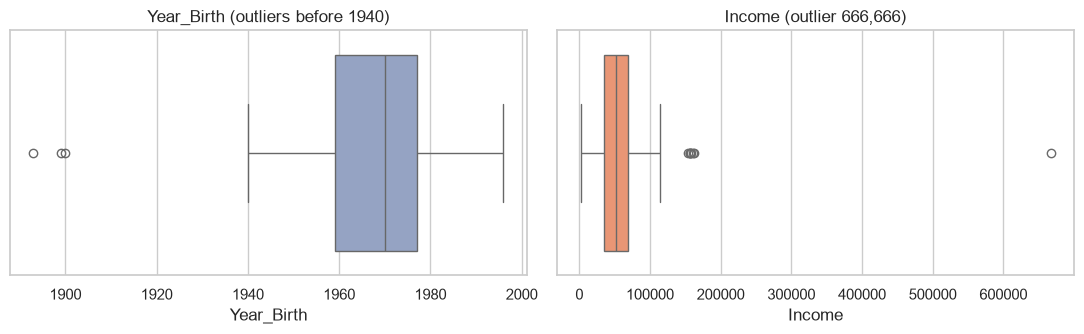

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
sns.boxplot(x=raw["Year_Birth"], ax=ax[0], color="#8da0cb"); ax[0].set_title("Year_Birth (outliers before 1940)")
sns.boxplot(x=raw["Income"], ax=ax[1], color="#fc8d62"); ax[1].set_title("Income (outlier 666,666)")
save("01_outliers_before_cleaning"); plt.show()

**Findings**
- **182 duplicate rows** (identical in all 28 columns except ID – the same customer registered twice) → remove.
- `Income` has **24 missing values** â†’ fill with the **median** (robust to outliers).
- `Z_CostContact` and `Z_Revenue` are **constant** (zero variance) â†’ drop. `ID` is just an identifier â†’ drop.
- `Year_Birth` has impossible values (1893, 1899, 1900 â†’ age 115+) â†’ remove rows with Year_Birth < 1940.
- `Income` has one extreme value (666,666) â†’ remove rows with Income > 600,000.
- `Marital_Status` contains invalid labels ("Absurd", "YOLO", "Alone") â†’ group into **Partner / Single**.
- `Education` has 5 levels â†’ group into **Undergraduate / Graduate / Postgraduate**.

### 1.3 Cleaning + feature engineering
The cleaning logic is written once in `utils.py` (`utils.clean`) so that the notebook and the dashboard use exactly the same preprocessing.

| New feature | Formula |
|---|---|
| Age | 2014 âˆ’ Year_Birth (data collected in 2014) |
| Total_Spent | sum of the 6 Mnt* columns |
| Children | Kidhome + Teenhome |
| Partner | 1 if Married/Together |
| Family_Size | 1 + Partner + Children |
| Is_Parent | 1 if Children > 0 |
| Total_Purchases | Deals + Web + Catalog + Store purchases |
| Total_Accepted_Cmp | AcceptedCmp1 + â€¦ + AcceptedCmp5 |
| Customer_Days | days since enrolment (up to latest enrolment date) |
| Edu_Code | 0 = Undergraduate, 1 = Graduate, 2 = Postgraduate |

In [6]:
df = utils.clean(raw)
print("Rows before:", len(raw), "| Rows after:", len(df), "| Removed:", len(raw) - len(df))
print("Missing values after cleaning:", df.isna().sum().sum())
print("\nEducation:", df["Education"].value_counts().to_dict())
print("Marital_Status:", df["Marital_Status"].value_counts().to_dict())
df[["Age", "Income", "Total_Spent", "Children", "Family_Size", "Total_Purchases",
    "Total_Accepted_Cmp", "Customer_Days", "Response"]].describe().round(1)

Rows before: 2240 | Rows after: 2054 | Removed: 186
Missing values after cleaning: 0

Education: {'Graduate': 1029, 'Postgraduate': 790, 'Undergraduate': 235}
Marital_Status: {'Partner': 1314, 'Single': 740}


,Age,Income,Total_Spent,Children,Family_Size,Total_Purchases,Total_Accepted_Cmp,Customer_Days,Response
count,2054.0,2054.0,2054.0,2054.0,2054.0,2054.0,2054.0,2054.0,2054.0
mean,45.1,52036.0,606.4,1.0,2.6,14.9,0.3,352.7,0.2
std,11.7,21465.0,602.4,0.7,0.9,7.7,0.7,202.2,0.4
min,18.0,1730.0,5.0,0.0,1.0,0.0,0.0,0.0,0.0
25%,37.0,35691.2,69.0,0.0,2.0,8.0,0.0,179.0,0.0
50%,44.0,51381.5,397.0,1.0,3.0,15.0,0.0,352.0,0.0
75%,55.0,68146.5,1046.5,1.0,3.0,21.0,0.0,528.0,0.0
max,74.0,162397.0,2525.0,3.0,5.0,44.0,4.0,699.0,1.0


In [7]:
df.to_csv("data/customers_clean.csv", index=False)
print("Saved cleaned dataset -> data/customers_clean.csv", df.shape)

Saved cleaned dataset -> data/customers_clean.csv (2054, 36)


## Step 2: Exploratory Data Analysis (Descriptive Analytics)
In this step we look at the cleaned data through charts to understand **who the customers are**, **how they spend**, **which channels they use** and **who responds to campaigns**. Each chart is followed by a short business insight.

In [8]:
df = pd.read_csv("data/customers_clean.csv", parse_dates=["Dt_Customer"])
print("Customers:", len(df), "| Overall response rate: {:.1%}".format(df["Response"].mean()))

Customers: 2054 | Overall response rate: 15.2%


### 2.1 Distribution of Age, Income and Total Spending

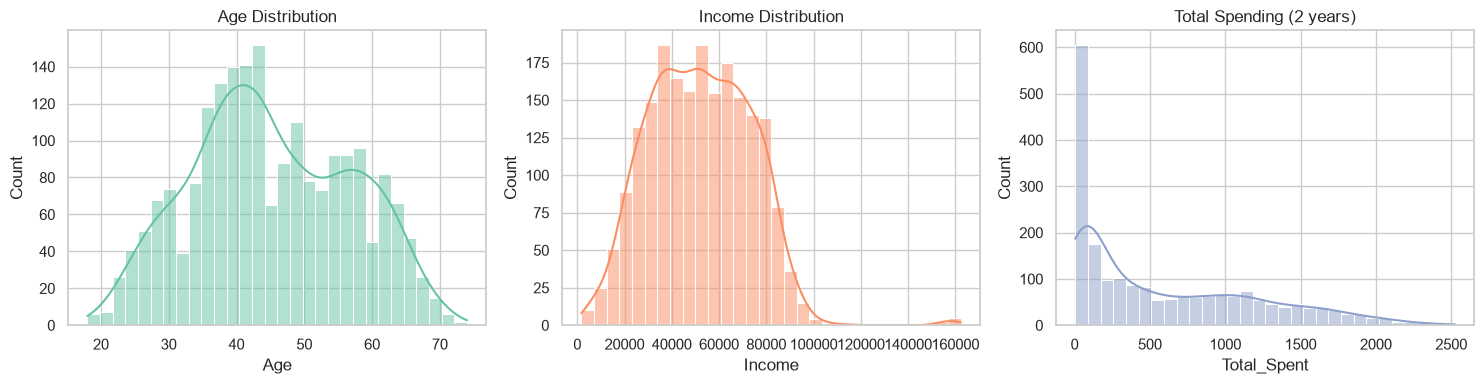

,Age,Income,Total_Spent
mean,45.11,52035.97,606.45
median,44.00,51381.50,397.00
std,11.67,21464.98,602.42
skew,0.10,0.37,0.87


In [9]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df["Age"], bins=30, kde=True, ax=ax[0], color="#66c2a5"); ax[0].set_title("Age Distribution")
sns.histplot(df["Income"], bins=30, kde=True, ax=ax[1], color="#fc8d62"); ax[1].set_title("Income Distribution")
sns.histplot(df["Total_Spent"], bins=30, kde=True, ax=ax[2], color="#8da0cb"); ax[2].set_title("Total Spending (2 years)")
save("02_distributions"); plt.show()
df[["Age", "Income", "Total_Spent"]].agg(["mean", "median", "std", "skew"]).round(2)

**Insight:** Customers are mostly middle-aged (median 44 years, range 18–74). Income is roughly normal around 52,000. **Total spending is strongly right-skewed** – most customers spend little, while a small group spends a lot. That high-value group is the most important to retain.

### 2.2 Customer profile: Education, Marital Status, Children and Response

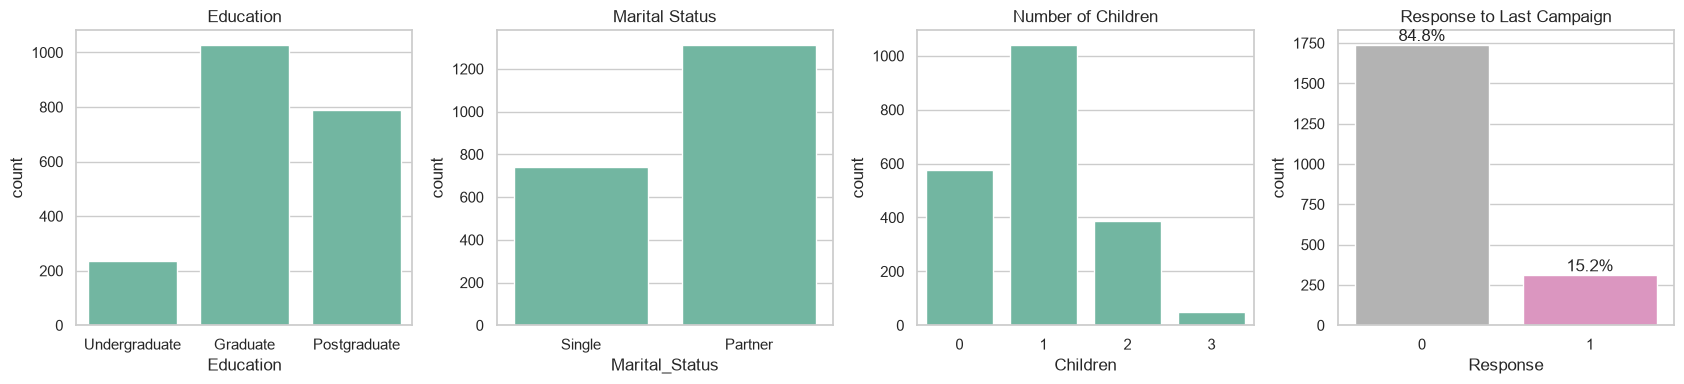

In [10]:
fig, ax = plt.subplots(1, 4, figsize=(17, 4))
sns.countplot(x="Education", data=df, ax=ax[0], order=["Undergraduate", "Graduate", "Postgraduate"]); ax[0].set_title("Education")
sns.countplot(x="Marital_Status", data=df, ax=ax[1]); ax[1].set_title("Marital Status")
sns.countplot(x="Children", data=df, ax=ax[2]); ax[2].set_title("Number of Children")
sns.countplot(x="Response", data=df, ax=ax[3], palette=["#b3b3b3", "#e78ac3"]); ax[3].set_title("Response to Last Campaign")
for p in ax[3].patches:
    ax[3].annotate(f"{p.get_height() / len(df):.1%}", (p.get_x() + p.get_width() / 2, p.get_height()), ha="center", va="bottom")
save("03_customer_profile"); plt.show()

**Insight:** Half the customers are graduates and about 64% live with a partner. Most households have 1 child/teen. **Only 15.2% responded to the last campaign** – the target classes are **imbalanced (85:15)**, which we must handle when building classification models (Step 6).

### 2.3 Income vs Total Spending

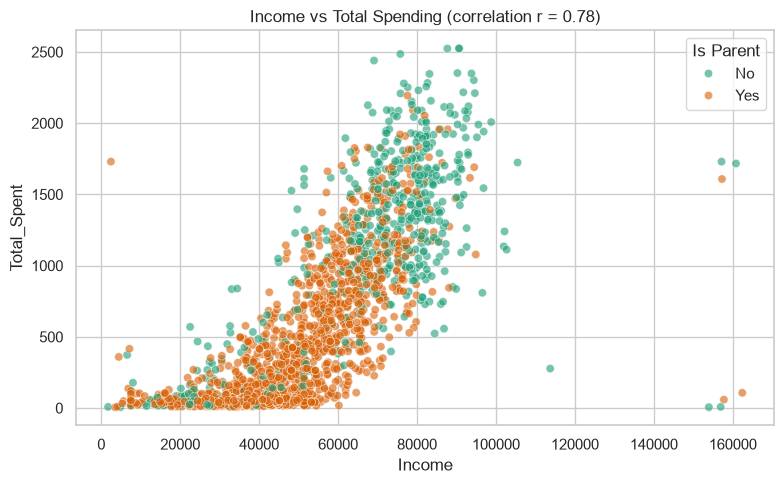

In [11]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df["Income"], y=df["Total_Spent"], hue=df["Is_Parent"].map({0: "No", 1: "Yes"}), alpha=0.6,
                palette={"No": "#1b9e77", "Yes": "#d95f02"})
plt.title(f"Income vs Total Spending (correlation r = {df['Income'].corr(df['Total_Spent']):.2f})")
plt.legend(title="Is Parent")
save("04_income_vs_spending"); plt.show()

**Insight:** There is a **strong positive relationship (r ≈ 0.78)** between income and spending – richer customers spend much more. Non-parents (green) dominate the high-spending region. This relationship is modelled formally with Linear Regression in Step 4.

### 2.4 Spending: Parents vs Non-Parents

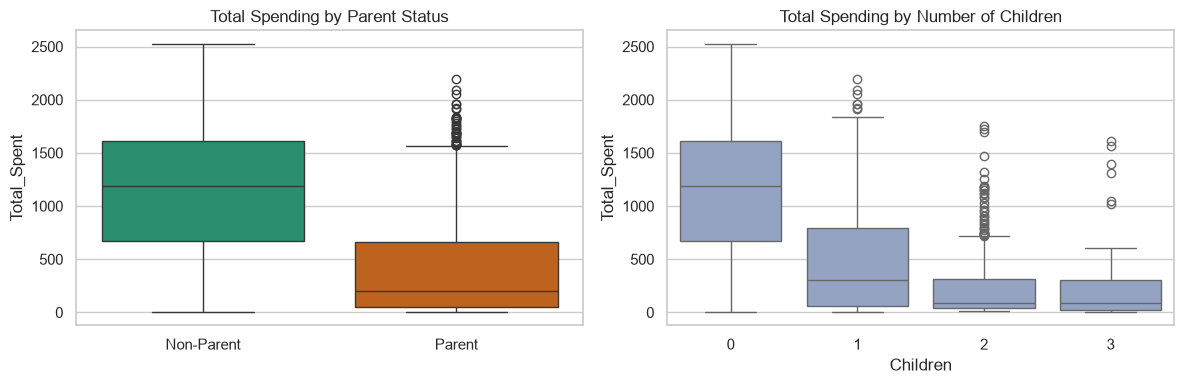

Is_Parent
Non-Parent    1192.5
Parent         202.0
Name: Total_Spent, dtype: float64

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x="Is_Parent", y="Total_Spent", data=df, ax=ax[0], palette=["#1b9e77", "#d95f02"])
ax[0].set_xticklabels(["Non-Parent", "Parent"]); ax[0].set_title("Total Spending by Parent Status"); ax[0].set_xlabel("")
sns.boxplot(x="Children", y="Total_Spent", data=df, ax=ax[1], color="#8da0cb"); ax[1].set_title("Total Spending by Number of Children")
save("05_spending_parents"); plt.show()
df.groupby("Is_Parent")["Total_Spent"].median().rename({0: "Non-Parent", 1: "Parent"})

**Insight:** Non-parents spend about **6 times more** (median ≈ 1,190 vs ≈ 200). Spending drops steadily as the number of children increases. Families need **discount / value offers**, while customers without children are the premium segment.

### 2.5 Spending by Product Category

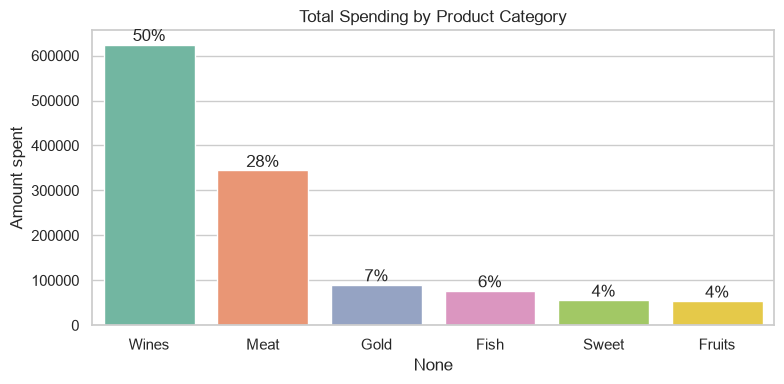

In [13]:
prod = df[utils.MNT_COLS].sum().sort_values(ascending=False)
prod.index = prod.index.str.replace("Mnt", "").str.replace("Products", "").str.replace("Prods", "")
plt.figure(figsize=(8, 4))
ax = sns.barplot(x=prod.index, y=prod.values, palette="Set2")
for i, v in enumerate(prod.values):
    ax.text(i, v, f"{v / prod.sum():.0%}", ha="center", va="bottom")
plt.title("Total Spending by Product Category"); plt.ylabel("Amount spent")
save("06_product_spending"); plt.show()

**Insight:** **Wine (50%) and Meat (28%) make up ~78% of all revenue.** Fruits, sweets and fish together are under 15%. Campaigns should focus on wine and meat offers; smaller categories can be used for cross-selling bundles.

### 2.6 Purchase Channels

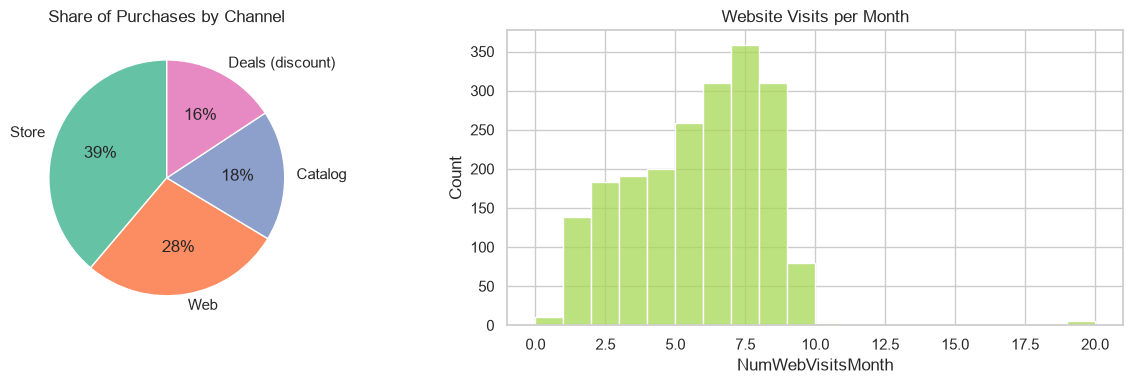

In [14]:
ch = df[["NumStorePurchases", "NumWebPurchases", "NumCatalogPurchases", "NumDealsPurchases"]].sum()
ch.index = ["Store", "Web", "Catalog", "Deals (discount)"]
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].pie(ch.values, labels=ch.index, autopct="%1.0f%%", startangle=90, colors=sns.color_palette("Set2"))
ax[0].set_title("Share of Purchases by Channel")
sns.histplot(df["NumWebVisitsMonth"], bins=20, ax=ax[1], color="#a6d854"); ax[1].set_title("Website Visits per Month")
save("07_purchase_channels"); plt.show()

**Insight:** **In-store is the main channel (39%)**, followed by Web (28%) and Catalog (18%). About 16% of purchases use a discount. Most customers visit the website 3–7 times a month (median 6), so **online campaigns can reach many customers at low cost**.

### 2.7 Acceptance Rate of Each Campaign

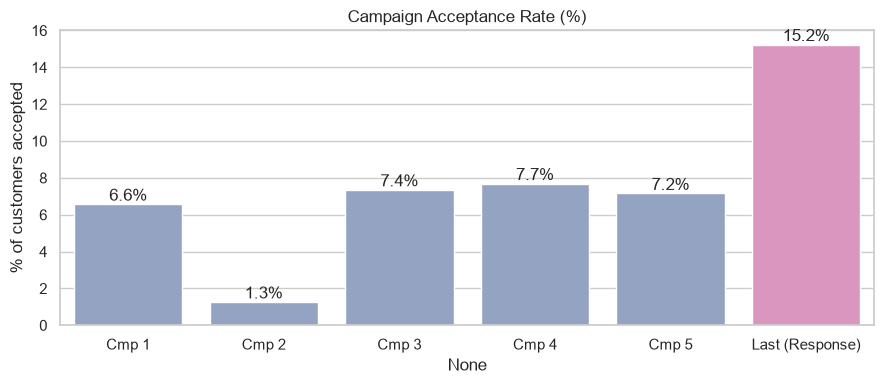

In [15]:
cmp = df[utils.CMP_COLS + ["Response"]].mean() * 100
cmp.index = ["Cmp 1", "Cmp 2", "Cmp 3", "Cmp 4", "Cmp 5", "Last (Response)"]
plt.figure(figsize=(9, 4))
ax = sns.barplot(x=cmp.index, y=cmp.values, palette=["#8da0cb"] * 5 + ["#e78ac3"])
for i, v in enumerate(cmp.values):
    ax.text(i, v, f"{v:.1f}%", ha="center", va="bottom")
plt.title("Campaign Acceptance Rate (%)"); plt.ylabel("% of customers accepted")
save("08_campaign_acceptance"); plt.show()

**Insight:** The first five campaigns had very low acceptance (1–8%); **Campaign 2 almost completely failed (1.3%)**. The most recent campaign did better (15.2%) but still **85% of customers were contacted for nothing**. This is exactly the wasted marketing spend that targeted campaigns can reduce.

### 2.8 Correlation Heatmap

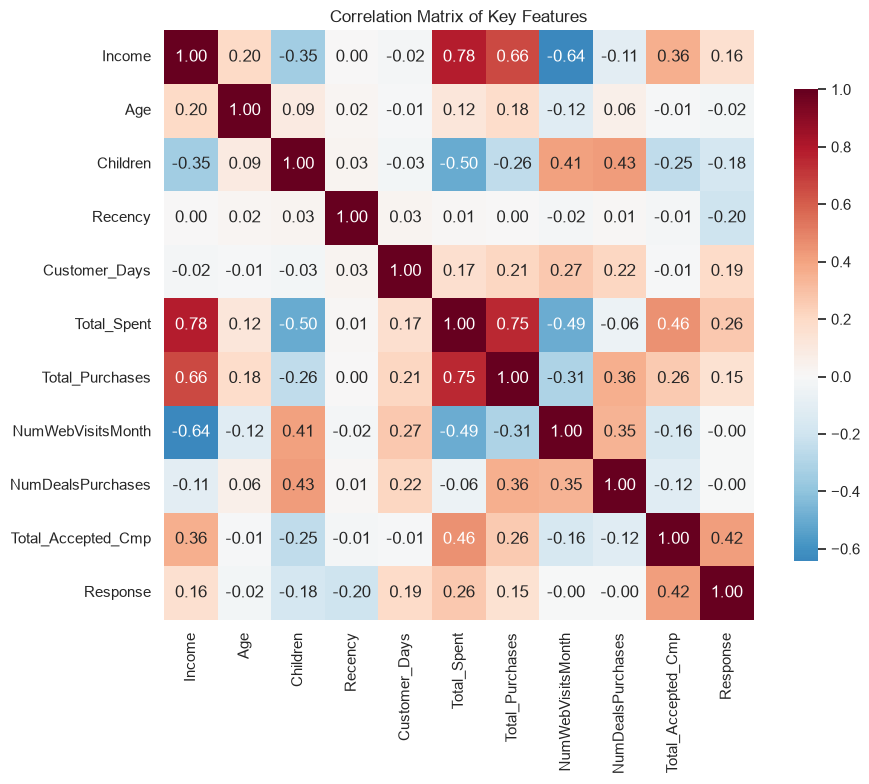

In [16]:
cols = ["Income", "Age", "Children", "Recency", "Customer_Days", "Total_Spent", "Total_Purchases",
        "NumWebVisitsMonth", "NumDealsPurchases", "Total_Accepted_Cmp", "Response"]
plt.figure(figsize=(10, 8))
sns.heatmap(df[cols].corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True, cbar_kws={"shrink": 0.8})
plt.title("Correlation Matrix of Key Features")
save("09_correlation_heatmap"); plt.show()

In [17]:
df.select_dtypes("number").corr()["Response"].drop("Response").sort_values(ascending=False).round(3).to_frame("Correlation with Response").head(8)

,Correlation with Response
Total_Accepted_Cmp,0.421
AcceptedCmp5,0.324
AcceptedCmp1,0.292
Total_Spent,0.263
AcceptedCmp3,0.249
MntWines,0.239
MntMeatProducts,0.237
NumCatalogPurchases,0.218


**Insight:** Income, Total_Spent and Total_Purchases are strongly correlated with each other. For **Response**, the strongest positive signal is **Total_Accepted_Cmp (0.42)** – customers who accepted earlier offers tend to accept again. **Recency** and **Children** are negatively related: recent buyers and customers without children respond more.

### 2.9 Who Responds to Campaigns?

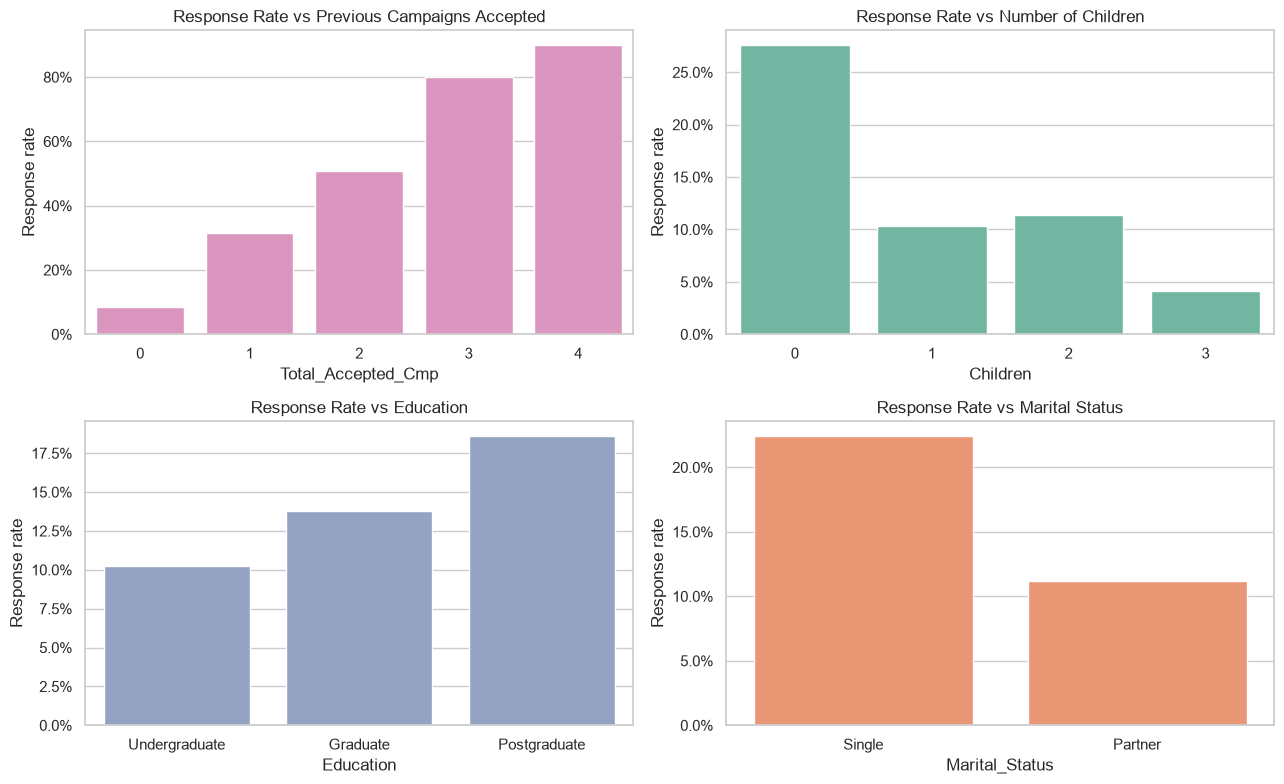

In [18]:
fig, ax = plt.subplots(2, 2, figsize=(13, 8))
sns.barplot(x="Total_Accepted_Cmp", y="Response", data=df, ax=ax[0, 0], errorbar=None, color="#e78ac3")
ax[0, 0].set_title("Response Rate vs Previous Campaigns Accepted")
sns.barplot(x="Children", y="Response", data=df, ax=ax[0, 1], errorbar=None, color="#66c2a5")
ax[0, 1].set_title("Response Rate vs Number of Children")
sns.barplot(x="Education", y="Response", data=df, ax=ax[1, 0], errorbar=None, order=["Undergraduate", "Graduate", "Postgraduate"], color="#8da0cb")
ax[1, 0].set_title("Response Rate vs Education")
sns.barplot(x="Marital_Status", y="Response", data=df, ax=ax[1, 1], errorbar=None, color="#fc8d62")
ax[1, 1].set_title("Response Rate vs Marital Status")
for a in ax.flat:
    a.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0)); a.set_ylabel("Response rate")
save("10_response_drivers"); plt.show()

**Insight:**
- Response rate rises sharply with past acceptances: **8% (0 previous) → 31% (1) → 51% (2) → 80%+ (3–4)**. Loyal responders are the best target.
- Customers **without children respond 28%** of the time vs ~10% for parents.
- **Singles respond twice as often (22%)** as customers living with a partner (11%).
- Postgraduates respond more (19%) than undergraduates (10%).

### 2.10 Responders vs Non-Responders

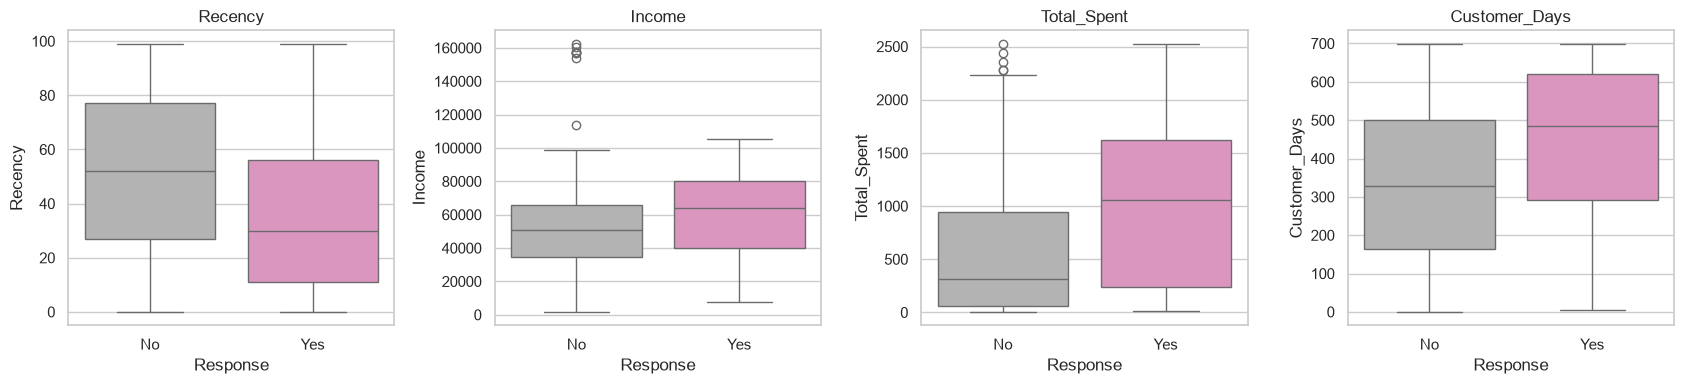

,Recency,Income,Total_Spent,Customer_Days
Response,,,,
No,51.0,50581.0,539.0,336.0
Yes,35.0,60127.0,980.0,443.0


In [19]:
fig, ax = plt.subplots(1, 4, figsize=(17, 4))
for a, col in zip(ax, ["Recency", "Income", "Total_Spent", "Customer_Days"]):
    sns.boxplot(x="Response", y=col, data=df, ax=a, palette=["#b3b3b3", "#e78ac3"])
    a.set_title(col); a.set_xticklabels(["No", "Yes"])
save("11_responders_vs_nonresponders"); plt.show()
df.groupby("Response")[["Recency", "Income", "Total_Spent", "Customer_Days"]].mean().round(0).rename(index={0: "No", 1: "Yes"})

**Insight:** Compared with non-responders, responders **bought more recently** (35 vs 51 days), **earn more** (≈60k vs ≈51k), **spend almost twice as much** (≈980 vs ≈540) and have been **customers for longer** (≈443 vs ≈336 days). Whether these differences are statistically significant is tested in Step 3.

### EDA Summary
1. Spending is driven mainly by **income** and **having no children**.
2. **Wine and meat** generate ~78% of revenue.
3. Only **15%** of customers respond to campaigns → most marketing spend is wasted today.
4. The best responders are **past responders, recent buyers, high spenders, singles and customers without children** – these patterns will be learned automatically by the classification models.

## Step 3: Sampling and Estimation
In real businesses we often cannot survey every customer, so we work with **samples** and **estimate** population values. In this step we:
1. Compute **point estimates** and **95% confidence intervals** (mean spending, mean income, response rate)
2. Show how **sample size** affects the width of a confidence interval
3. Compare **Simple Random Sampling vs Stratified Sampling**
4. Use **Bootstrap resampling** to estimate a confidence interval (Central Limit Theorem demo)
5. Calculate the **sample size** required for a marketing survey
6. Run **hypothesis tests** (t-test, chi-square) to check whether the EDA differences are statistically significant

In [20]:
from scipy import stats
from sklearn.model_selection import train_test_split

def mean_ci(x, conf=0.95):
    x = pd.Series(x).dropna()
    lo, hi = stats.t.interval(conf, len(x) - 1, loc=x.mean(), scale=stats.sem(x))
    return x.mean(), lo, hi

def prop_ci(x, conf=0.95):
    p, n = np.mean(x), len(x)
    z = stats.norm.ppf(1 - (1 - conf) / 2)
    se = np.sqrt(p * (1 - p) / n)
    return p, p - z * se, p + z * se

### 3.1 Point Estimates and 95% Confidence Intervals
- **Mean (t-interval):** x̄ ± t(α/2, n−1) · s/√n
- **Proportion (z-interval):** p̂ ± z(α/2) · √(p̂(1−p̂)/n)

In [21]:
rows = []
for col in ["Total_Spent", "Income", "Age", "Recency"]:
    m, lo, hi = mean_ci(df[col])
    rows.append([f"Mean {col}", m, lo, hi])
p, lo, hi = prop_ci(df["Response"])
rows.append(["Response rate (proportion)", p, lo, hi])
ci_table = pd.DataFrame(rows, columns=["Parameter", "Point Estimate", "95% CI Lower", "95% CI Upper"])
ci_table.round(3)

,Parameter,Point Estimate,95% CI Lower,95% CI Upper
0,Mean Total_Spent,606.446,580.379,632.514
1,Mean Income,52035.971,51107.145,52964.797
2,Mean Age,45.112,44.608,45.617
3,Mean Recency,48.959,47.704,50.214
4,Response rate (proportion),0.152,0.137,0.168


**Interpretation:**
- We are 95% confident that the true **average 2-year spending** of a customer lies between **≈580 and ≈633**.
- We are 95% confident that the true **campaign response rate** lies between **13.7% and 16.8%**.

*Meaning of 95% confidence:* if we repeated the sampling many times, about 95% of the intervals built this way would contain the true population value.

### 3.2 Effect of Sample Size on the Confidence Interval
We draw random samples of different sizes and compute the 95% CI of mean spending for each.

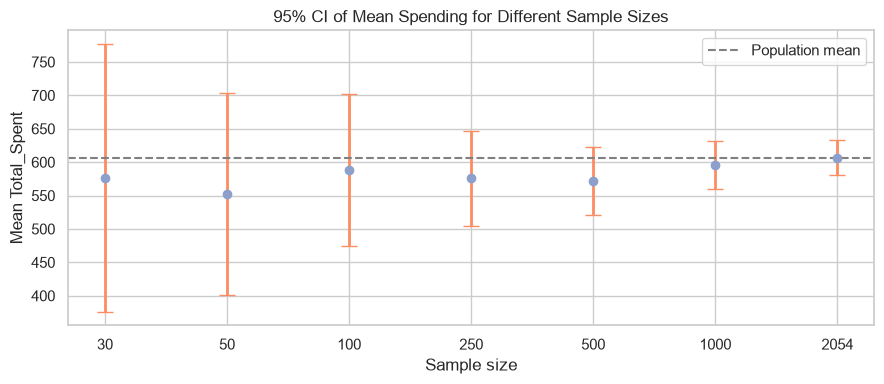

,Sample size,Mean,Lower,Upper,CI width
0,30,576.5,375.8,777.1,401.3
1,50,552.4,400.7,704.1,303.4
2,100,588.2,473.8,702.7,228.9
3,250,575.9,504.6,647.1,142.5
4,500,572.1,521.5,622.7,101.1
5,1000,595.4,559.2,631.7,72.6
6,2054,606.4,580.4,632.5,52.1


In [22]:
sizes = [30, 50, 100, 250, 500, 1000, len(df)]
res = []
for n in sizes:
    s = df["Total_Spent"].sample(n, random_state=1)
    m, lo, hi = mean_ci(s)
    res.append([n, m, lo, hi, hi - lo])
size_df = pd.DataFrame(res, columns=["Sample size", "Mean", "Lower", "Upper", "CI width"])

plt.figure(figsize=(9, 4))
plt.errorbar(size_df["Sample size"].astype(str), size_df["Mean"],
             yerr=[size_df["Mean"] - size_df["Lower"], size_df["Upper"] - size_df["Mean"]],
             fmt="o", capsize=6, color="#8da0cb", ecolor="#fc8d62", lw=2)
plt.axhline(df["Total_Spent"].mean(), ls="--", color="grey", label="Population mean")
plt.title("95% CI of Mean Spending for Different Sample Sizes"); plt.xlabel("Sample size"); plt.ylabel("Mean Total_Spent")
plt.legend(); save("12_ci_vs_sample_size"); plt.show()
size_df.round(1)

**Insight:** As the sample size increases, the confidence interval becomes **much narrower** (width shrinks roughly with 1/√n). Small samples (n = 30) give very uncertain estimates; with ~500 customers the estimate is already quite precise.

### 3.3 Simple Random Sampling vs Stratified Sampling
Response is imbalanced (15% Yes). We draw **200 samples of 300 customers** each way and compare how well each method preserves the true response rate.
- **Simple Random Sampling (SRS):** every customer has an equal chance of selection.
- **Stratified Sampling:** the population is split into strata (Response = 0 / 1) and each stratum is sampled in proportion.

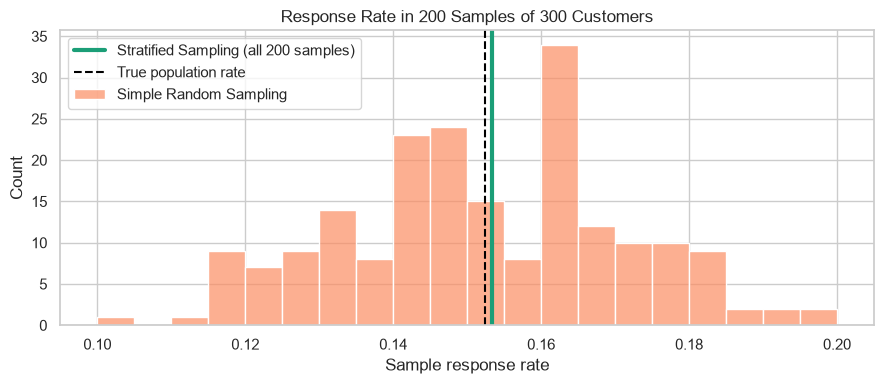

,Method,Mean response rate,Std deviation,Min,Max
0,Simple Random,0.1519,0.0187,0.1000,0.2000
1,Stratified,0.1533,0.0000,0.1533,0.1533


In [23]:
srs_rates, strat_rates = [], []
for i in range(200):
    srs_rates.append(df.sample(300, random_state=i)["Response"].mean())
    _, s = train_test_split(df, test_size=300, stratify=df["Response"], random_state=i)
    strat_rates.append(s["Response"].mean())

plt.figure(figsize=(9, 4))
sns.histplot(srs_rates, bins=20, color="#fc8d62", label="Simple Random Sampling", alpha=0.7)
plt.axvline(np.mean(strat_rates), color="#1b9e77", lw=3, label="Stratified Sampling (all 200 samples)")
plt.axvline(df["Response"].mean(), color="black", ls="--", label="True population rate")
plt.title("Response Rate in 200 Samples of 300 Customers"); plt.xlabel("Sample response rate")
plt.legend(); save("13_srs_vs_stratified"); plt.show()

pd.DataFrame({"Method": ["Simple Random", "Stratified"],
              "Mean response rate": [np.mean(srs_rates), np.mean(strat_rates)],
              "Std deviation": [np.std(srs_rates), np.std(strat_rates)],
              "Min": [np.min(srs_rates), np.min(strat_rates)],
              "Max": [np.max(srs_rates), np.max(strat_rates)]}).round(4)

**Insight:** With simple random sampling the response rate in a sample varied from **10% to 20%** just by chance. **Stratified sampling kept it at ≈15.3% every time** (zero variation). This is why we use **stratified train/test splitting** (`stratify=y`) for the classification models in Step 6 – both training and testing sets will have the same 15% responders.

### 3.4 Bootstrap Confidence Interval and the Central Limit Theorem
Bootstrap = resample the data **with replacement** many times, compute the mean each time, and use the spread of those means to estimate the confidence interval. It does not assume any distribution.

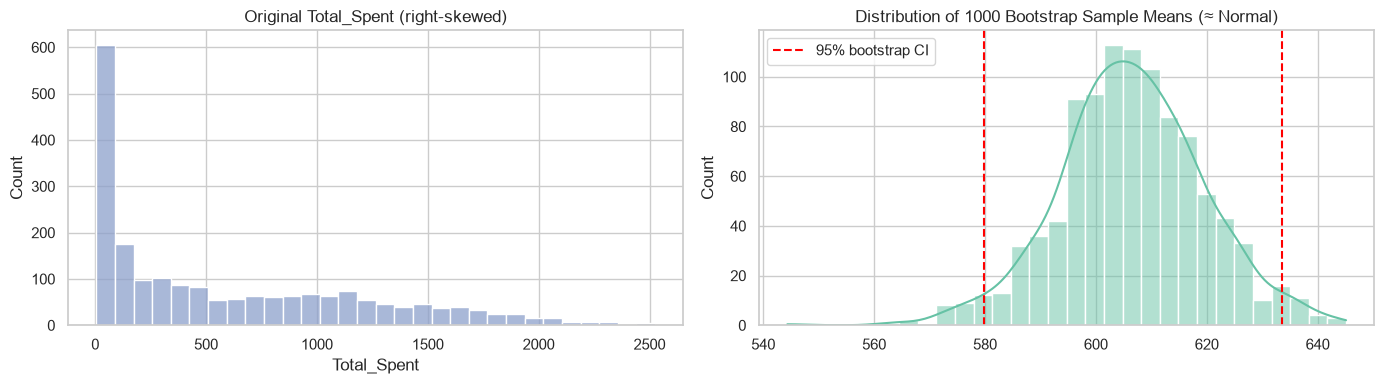

Bootstrap 95% CI : (579.7, 633.5)
t-based 95% CI   : (580.4, 632.5)


In [24]:
boot_means = [df["Total_Spent"].sample(len(df), replace=True, random_state=i).mean() for i in range(1000)]
b_lo, b_hi = np.percentile(boot_means, [2.5, 97.5])

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df["Total_Spent"], bins=30, ax=ax[0], color="#8da0cb")
ax[0].set_title("Original Total_Spent (right-skewed)")
sns.histplot(boot_means, bins=30, kde=True, ax=ax[1], color="#66c2a5")
ax[1].axvline(b_lo, color="red", ls="--"); ax[1].axvline(b_hi, color="red", ls="--", label="95% bootstrap CI")
ax[1].set_title("Distribution of 1000 Bootstrap Sample Means (≈ Normal)"); ax[1].legend()
save("14_bootstrap_clt"); plt.show()

t_mean, t_lo, t_hi = mean_ci(df["Total_Spent"])
print(f"Bootstrap 95% CI : ({b_lo:.1f}, {b_hi:.1f})")
print(f"t-based 95% CI   : ({t_lo:.1f}, {t_hi:.1f})")

**Insight:** Even though spending itself is heavily skewed, the **distribution of sample means is bell-shaped (normal)** – this is the **Central Limit Theorem**. The bootstrap CI (≈580–633) almost exactly matches the t-based CI, confirming our estimate.

### 3.5 Sample Size Planning for a Marketing Survey
Suppose the company wants to estimate the response rate of a new campaign through a pilot test. How many customers must be contacted to estimate it within a margin of error **E**?

**Formula:** n = z² · p(1−p) / E²  (using p = 0.152 from past data)

In [25]:
p0 = df["Response"].mean()
plan = []
for conf in [0.90, 0.95, 0.99]:
    z = stats.norm.ppf(1 - (1 - conf) / 2)
    for E in [0.05, 0.03, 0.02]:
        plan.append([f"{conf:.0%}", f"±{E:.0%}", int(np.ceil(z**2 * p0 * (1 - p0) / E**2))])
pd.DataFrame(plan, columns=["Confidence", "Margin of error", "Required sample size"]).pivot(
    index="Confidence", columns="Margin of error", values="Required sample size")

Margin of error,±2%,±3%,±5%
Confidence,,,
90%,874,389,140
95%,1241,552,199
99%,2143,953,343


**Insight:** To estimate the response rate within **±3% at 95% confidence**, a pilot campaign needs only **≈550 customers**, not the whole customer base. Higher confidence or a smaller margin of error needs a bigger sample.

### 3.6 Hypothesis Testing
We test whether the differences seen in the EDA are **real (statistically significant)** or due to chance. Significance level **α = 0.05**.

**(a) Welch two-sample t-test** – numeric variables, responders vs non-responders
- H₀: mean of the variable is the same for responders and non-responders
- H₁: the means are different

In [26]:
t_rows = []
for col in ["Total_Spent", "Income", "Recency", "Customer_Days", "Age", "NumWebVisitsMonth"]:
    yes, no = df.loc[df["Response"] == 1, col], df.loc[df["Response"] == 0, col]
    t, pval = stats.ttest_ind(yes, no, equal_var=False)
    t_rows.append([col, yes.mean(), no.mean(), t, pval, "Reject H₀ (significant)" if pval < 0.05 else "Fail to reject H₀"])
pd.DataFrame(t_rows, columns=["Variable", "Mean (Responders)", "Mean (Non-responders)", "t-statistic", "p-value", "Decision"]).round(4)

,Variable,Mean (Responders),Mean (Non-responders),t-statistic,p-value,Decision
0,Total_Spent,979.9872,539.2906,10.3247,0.0000,Reject H₀ (significant)
1,Income,60127.1805,50581.3191,6.8288,0.0000,Reject H₀ (significant)
2,Recency,35.0639,51.4572,-9.6819,0.0000,Reject H₀ (significant)
3,Customer_Days,442.9617,336.4383,8.6872,0.0000,Reject H₀ (significant)
4,Age,44.4760,45.2269,-0.9976,0.3191,Fail to reject H₀
5,NumWebVisitsMonth,5.3035,5.3257,-0.1418,0.8873,Fail to reject H₀


**(b) Chi-square test of independence** – categorical variables vs Response
- H₀: the variable and Response are independent
- H₁: they are associated

In [27]:
c_rows = []
for col in ["Education", "Marital_Status", "Is_Parent", "Complain"]:
    chi2, pval, dof, _ = stats.chi2_contingency(pd.crosstab(df[col], df["Response"]))
    c_rows.append([col, chi2, dof, pval, "Reject H₀ (associated)" if pval < 0.05 else "Fail to reject H₀"])
pd.DataFrame(c_rows, columns=["Variable", "Chi-square", "df", "p-value", "Decision"]).round(4)

,Variable,Chi-square,df,p-value,Decision
0,Education,13.1868,2,0.0014,Reject H₀ (associated)
1,Marital_Status,45.4803,1,0.0000,Reject H₀ (associated)
2,Is_Parent,93.4369,1,0.0000,Reject H₀ (associated)
3,Complain,0.0000,1,1.0000,Fail to reject H₀


**Insight:**
- Responders **spend significantly more**, **earn more**, **bought more recently** and have been **customers longer** (all p < 0.001). The EDA differences are real, not random.
- **Education, Marital Status and Parent status are all significantly associated** with Response (p < 0.01).
- **Age (p = 0.32) and website visits (p = 0.89) do NOT differ significantly** – responders are not younger or more active online.
- **Complain has no relationship** with Response (p = 1.0), so it is a weak predictor.

### Sampling & Estimation Summary
1. Average customer spending is **606 (95% CI: 580–633)**; response rate is **15.2% (95% CI: 13.7%–16.8%)**.
2. Larger samples give narrower, more reliable estimates.
3. **Stratified sampling** preserves the response ratio exactly – used for the train/test split in Step 6.
4. The bootstrap confirms the CI and demonstrates the **Central Limit Theorem**.
5. A pilot campaign of **~550 customers** is enough to estimate response within ±3%.
6. Hypothesis tests confirm that spending, income, recency, tenure, marital status and children **significantly** influence response.